# Explora aquí

Se recomienda utilizar este cuaderno con fines de exploración.

HTML descargado correctamente
26
101
99
  Rank               Song                    Artist Streams  \
0    1  "Blinding Lights"                The Weeknd   5.358   
1    2     "Shape of You"                Ed Sheeran   4.852   
2    3  "Sweater Weather"         The Neighbourhood   4.511   
3    4          "Starboy"  The Weeknd and Daft Punk   4.465   
4    5        "As It Was"              Harry Styles   4.342   

         ReleaseDate Reference  
0   29 November 2019       [1]  
1     6 January 2017       [2]  
2    3 December 2012       [3]  
3  21 September 2016       [4]  
4       1 April 2022       [5]  


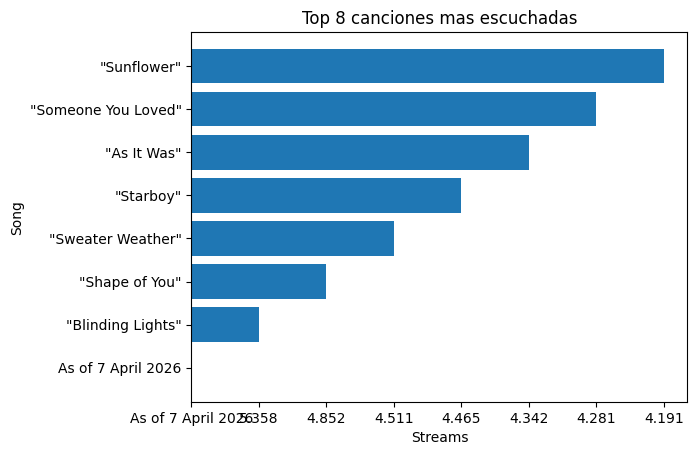

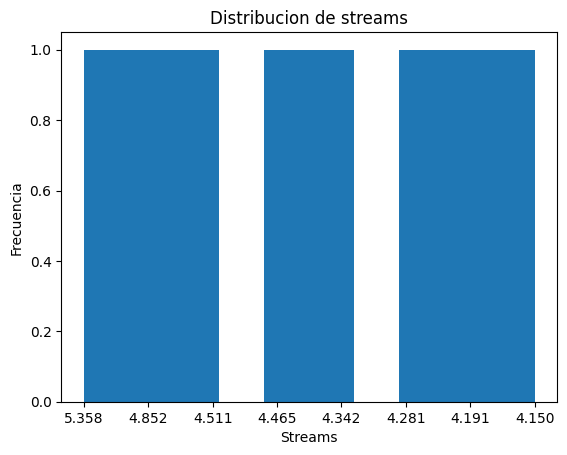

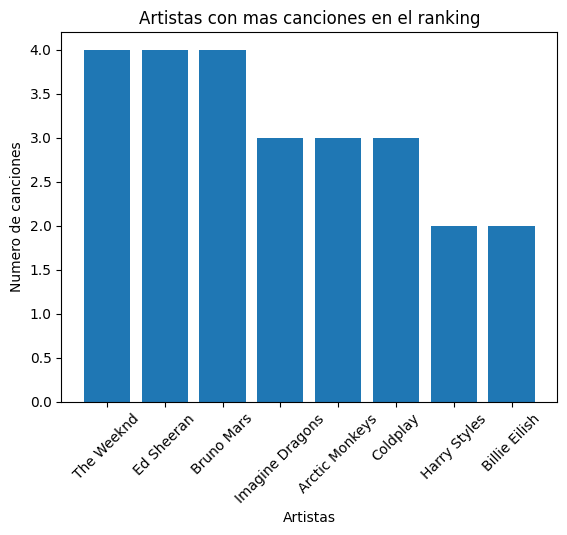

In [ ]:
import os
from bs4 import BeautifulSoup
import requests
import time
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import io

#PASO 2

# Seleccionar el recurso a descargar
resource_url = "https://en.wikipedia.org/wiki/List_of_most-streamed_songs_on_Spotify"

#he puesto headers porque si no,no me dejaba,no se porque,lo he buscado en internet
#y me salia algo asi como que me detectaba como si fuera un bot,y me daba un error
#de seguridad(403)
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Petición para descargar el fichero de Internet
response = requests.get(resource_url,headers=headers)

if response.status_code == 200:
    html = response.text
    print ("HTML descargado correctamente")
else:
    print ("Error: ",response.status_code)


#PASO 3

html2 = io.StringIO(html)
tablas = pd.read_html(html2)
print (len(tablas))

df = tablas[0]
df.head()

#PASO 4

#eliminamos filas con datos nulos
print(len(df))
df_filasvacias = df.dropna()
print (len(df_filasvacias))

#quitamos espacios al inicio y al final de nombres de canciones y artistas,y quitamos
#los sibolos o comas

#quitamos los espacios al final y al principio
df_filasvacias['Song'] = df_filasvacias['Song'].str.strip()
df_filasvacias['Artist(s)'] = df_filasvacias['Artist(s)'].str.strip()

#quitamos comas 
df_filasvacias['Streams (billions)'] = df_filasvacias['Streams (billions)'].str.replace(',', '')

#convertimos los string de la columna stream a flotantes,esto funcionaria si en una
#fila no estuviera este dato que es una fecha 'As of 7 April 2026',por eso no se puede
#convertir a flotante para en un futuro hacer operaciones o lo que sea con esos datos

#df_filasvacias["Streams (billions)"] = df_filasvacias["Streams (billions)"].astype(float)

#aqui cambiamos los nombres de las columnas para que sean mas legibles
#para que luego a la hora de hacer la base de datos no haya problemas
df_filasvacias = df_filasvacias.rename(columns={
    'Artist(s)': 'Artist',
    'Streams (billions)': 'Streams',
    'Release date': 'ReleaseDate',
    'Ref.': 'Reference'
})



#mirtamos el resultado
print(df_filasvacias.head())






#PASO 5
conn = sqlite3.connect("spotify.db")
cursor = conn.cursor()

#creamos la tabla con el metodo to_sql,que cogemos el df de antes,con el parametro
#de conn,que es la base de datos
df_filasvacias.to_sql("canciones",conn,if_exists="replace",index=False)

#alamcenamos los cambios
conn.commit()
conn.close()



#PASO 6

#Grafico de barras
top10 = df_filasvacias.sort_values(by="Streams",ascending=False).head(8)

plt.Figure()
plt.barh(top10["Song"],top10["Streams"])
plt.xlabel("Streams")
plt.ylabel("Song")
plt.title("Top 8 canciones mas escuchadas")
plt.show()

#histograma
plt.figure()
plt.hist(df_filasvacias["Streams"].head(8))
plt.xlabel("Streams")
plt.ylabel("Frecuencia")
plt.title("Distribucion de streams")
plt.show()

#grafico de barras de frecuencias

artistas = df_filasvacias["Artist"].value_counts().head(8)

plt.Figure()
plt.bar(artistas.index,artistas.values)
plt.xticks(rotation=45)
plt.xlabel("Artistas")
plt.ylabel("Numero de canciones")
plt.title("Artistas con mas canciones en el ranking")
plt.show()
